<div >
<img src = "figs/ans_banner_1920x200.png" />
</div>

# Semana 6. Sesión Sincrónica.

El  *cuaderno* tiene  como objetivo introducir a los estudiantes a los contenidos de la semana 6.

**NO** es necesario editar el archivo o hacer una entrega. Los ejemplos contienen celdas con código ejecutable (`en gris`), que podrá modificar libremente. Esta puede ser una buena forma de aprender nuevas funcionalidades del *cuaderno*, o experimentar variaciones en los códigos de ejemplo.



## ¿Qué son los sistemas de recomendaciones?


Las preferencias de los individuos suelen seguir patrones que los sistemas de recomendación pueden aprovechar, por ejemplo,

- Si te interesó:  <div style="max-width:200px">
<img src = "figs/iron_man.jpg" />
</div>


- También te puede interesar: <div style="max-width:200px">
<img src = "figs/thor.jpg" />
</div> 




- Los sistemas de recomendación entonces encuentran patrones que son utilizados para predecir qué otros productos podrían gustarnos y generar sugerencias, de forma tal que  los usuarios encuentren contenido atractivo en un gran corpus. 

- Estos sistemas son muy exitosos, por ejemplo según un estudio del 2013 de [McKinsey](https://www.mckinsey.com/industries/retail/our-insights/how-retailers-can-keep-up-with-consumers), el 35% de los artículos comprados en Amazon surgen de estos sistemas de recomendación, y por lo tanto vale la pena estudiarlos cuidadosamente.

# Previamente ...

Los cinco motores de la semana 5 (popularidad simple, popularidad ponderada, coseno entre usuarios, factores latentes por SVD y reglas de asociación) comparten un supuesto: que alguien ya interactuó con el ítem.

Sin embargo, si tenemos, un ítem nuevo, que nadie calificó todavía, su columna está vacía. Ningún recomendador lo puede ofrecer. O si tenemos un usuario nuevo, su fila está vacía. No hay vecinos ni factores que estimar.

Este es el problema del **arranque en frío (cold start)** . Una solución es utilizar información del artículo: una descripción, 
una sinopsis, unas reseñas. 

Eso es el **filtrado basado en contenido**: recomendar por lo que el ítem *es*, no
por quién lo consumió. Este tipo de recomendadores, no reemplazan al colaborativo; lo complementa justo en la dimensión donde el colaborativo no llega.

# Filtrado  Basado en Contenido. Análisis de textos


- Los sistemas basados en contenido, a diferencia de los filtros colaborativos, no requieren datos relacionados a otros individuos u actividades pasadas. 


- Por el contrario, estos brindan recomendaciones basadas en el perfil del usuario y los metadatos que se tiene sobre elementos particulares.


- Parte importante viene de la descripción de los items y esta descripción esta por lo general expresada en texto.


- Visitaremos entonces brevemente como aprovechar esta información para mejorar las recomendaciones.


- Para ello tenemos que encontrar el significado de las expresiones

    - El principio de composicionalidad, que tiene su origen en la filosofía del lenguaje, dice que el significado de una expresión es una función de los significados de sus subexpresiones. 
    - El significado de una oración es una función de los significados de sus frases, el significado de una frase es una función de los significados de sus palabras, y el significado de una palabra es una función de los significados de sus lexemas. 


- Habiendo determinado la estructura de un fragmento de texto, encontrar su significado puede verse como un proceso de abajo hacia arriba, desde los lexemas en la parte inferior pasando por los morfemas, las oraciones, los temas, y más allá.

In [1]:
#cargamos librerias
import pandas as pd
import numpy as np

In [2]:
# Cargamos y visualizamos  los datos
ratings = pd.read_csv('data/Ratings.csv', encoding='latin-1')
ratings

,restaurant_id,user_id,rating,comentarios
0,1,1,5.0,"Excelente zerbicio, la comida deliziosa."
1,1,2,4.0,NaN
2,1,3,3.0,Comida mala y mal servicio
3,1,4,NaN,NaN
4,1,5,NaN,NaN
5,2,1,4.0,NaN
6,2,2,3.0,NaN
7,2,3,2.0,Pésima comida y pésimo servicio
8,2,4,NaN,NaN
9,2,5,NaN,NaN


In [3]:
ratings=ratings.dropna()
ratings

,restaurant_id,user_id,rating,comentarios
0,1,1,5.0,"Excelente zerbicio, la comida deliziosa."
2,1,3,3.0,Comida mala y mal servicio
7,2,3,2.0,Pésima comida y pésimo servicio
10,3,1,5.0,"Comida deliciosa, el servicio excelente!"
11,3,2,4.0,"Excelente servicio, buena comida"
12,3,3,3.0,"La comida llegó fría, el serbizio fue muy malo!"
18,4,4,4.0,"Buena comida, buen servicio"
19,4,5,4.0,"Buen menu, servicio excelente"
23,5,4,5.0,Excelente comida y servicio


- Necesitamos procesar el texto para que sea útil y poder capturar significado de las palabras a través de los morfemas.

- Vamos a realizar unos pasos previos

    - Remover elementos como stopwords, tildes, signos de puntuación, números, y cualquier otro símbolo que pueden llegar a entorpecer el análisis. En este paso las expresiones regulares son especialmente útiles. 
    
  - Separar el texto en palabras o *tokens*
  
  - Encontrar los morfemas o lexemas via *lematización* o *stemming*

##### Comencemos con la limpieza de los comentarios

- Voy a mostrarles como hacerlo con la librería de procesamiento y análisis de texto, ConTexto, desarrollada por el DNP de Colombia.


- Ver https://ucd-dnp.github.io/ConTexto/versiones/master/index.html

In [4]:
print(ratings['comentarios'][12]) 

La comida llegó fría, el serbizio fue muy malo!


In [5]:
# Cargamos las librerías a utilizar ()
from contexto.limpieza import *

from contexto.correccion import Corrector, corregir_texto


texto_corregido = corregir_texto(ratings['comentarios'][12])
print(texto_corregido)

La comida llegó fría, el servicio fue muy malo!


In [6]:
# Para quitar acentos (diéresis, tildes y virgulillas)
texto_corregido=remover_acentos(texto_corregido)
texto_corregido

'La comida llego fria, el servicio fue muy malo!'

In [7]:
import spacy
nlp = spacy.load("es_core_news_sm")

# Cargamos las stopwords extra
extra_stopwords = pd.read_csv('data/extra_stopwords.csv', sep=',',header=None)
extra_stopwords.columns = ['stopwords']
extra_stopwords=set(extra_stopwords['stopwords'].to_list())

# Agregamos a nuestro modelo de SpaCy
nlp.Defaults.stop_words |= extra_stopwords

#print(nlp.Defaults.stop_words) # Mostrar la nueva lista de stopwords

In [8]:
# corremos limpieza de texto
texto_corregido=limpieza_texto(texto_corregido,lista_palabras=extra_stopwords)
texto_corregido

'comida llego fria servicio malo'

##### Lematización
 
- Operación que consiste en transformar las palabras de su forma flexionada (plural, femenino, conjugaciones, etc.) a su lema correspondiente, el cual es el representante de todas las formas flexionadas de una misma palabra. 
 
 
 - Por ejemplo, las palabras niños, niña y niñito tienen todas el mismo lema: niño. 
 
 
 - Realizar lematización sobre textos puede simplificarlos, al unificar palabras que comparten el mismo lema, y evitando así tener un vocabulario más grande de lo necesario.

In [9]:
#La primera vez que se utilice una combinación particular de lenguaje + tamaño, la librería descargará el modelo correspondiente en el computador del usuario. 
#Para usarlo, se debe reiniciar la sesión y correr la función de nuevo.
from contexto.lematizacion import LematizadorSpacy
from contexto.lematizacion import lematizar_texto


texto_corregido = lematizar_texto(texto_corregido)

texto_corregido

[INFO] Descargando modelo. Este proceso puede tardar varios minutos.


[INFO] El modelo ha sido descargado.
[INFO] Por favor correr de nuevo el script, o iniciar una nueva sesión de Python para cargarlo.
[INFO] Hasta entonces, se utilizará un modelo en blanco.



'    '

In [10]:
# Agregar lemas desde un diccionario

segundo_dict = {
    "llego" : "llegar",
    "deliciós": "delicioso",
    "comido": "comida",
    "malo":"mal"
    
}
texto_lematizado = lematizar_texto(texto_corregido, dict_lemmas=segundo_dict)
print(texto_lematizado)


##### Stemming 

- El stemming es un método para reducir todas las formas flexionadas de palabras a su «raíz» o «tallo» (stem, en inglés), cuando estas comparten una misma raíz.


- Por ejemplo, las palabras niños, niña y niñez tienen todas la misma raíz: «niñ». A diferencia de la lematización, en donde cada lema es una palabra que existe en el vocabulario del lenguaje correspondiente, las palabras raíz que se obtienen al aplicar stemming no necesariamente existen por sí solas como palabra.


- Aplicar stemming a textos puede simplificarlos, al unificar palabras que comparten la misma raíz, y evitando así tener un vocabulario más grande de lo necesario.

In [11]:
from contexto.stemming import Stemmer, stem_texto

# Determinar automáticamente el lenguaje del texto
texto_stem = stem_texto(texto_lematizado, 'auto')
print(texto_stem)

- Podemos definir todas juntas

In [12]:
ratings['comentarios']

0           Excelente zerbicio, la comida deliziosa. 
2                          Comida mala y mal servicio
7                     Pésima comida y pésimo servicio
10           Comida deliciosa, el servicio excelente!
11                   Excelente servicio, buena comida
12    La comida llegó fría, el serbizio fue muy malo!
18                       Buena comida, buen servicio 
19                      Buen menu, servicio excelente
23                        Excelente comida y servicio
Name: comentarios, dtype: object

In [13]:
# Funcion que limpia el texto y separa en tokens
def text_cleaning(txt):

    out = corregir_texto(txt)
    out = remover_acentos(out)
    out = limpieza_texto(out,lista_palabras=extra_stopwords)
    out = lematizar_texto(out)
    out = lematizar_texto(out, dict_lemmas=segundo_dict)
#   out = stem_texto(out, 'auto')
    return out


clean = ratings['comentarios'].apply(text_cleaning)
clean

0     excelente servicio comida delicioso
2                 comida mal mal servicio
7           pesimo comida pesimo servicio
10    comida delicioso servicio excelente
11         excelente servicio buen comida
12        comida llegar frio servicio mal
18              buen comida buen servicio
19           buen menu servicio excelente
23              excelente comida servicio
Name: comentarios, dtype: object

## Un corpus mas complejo

Para hacer modelado de tópicos necesitamos mas información.  Así que vamos a trabajar con **800 reseñas sintéticas**. Estas las generamos haciendo "ingenieria reversa" de LDA. Esto implica que nosotros conocemos la verdad: sabemos cuántos temas hay, cuáles son, y en qué proporción entró cada tema en cada reseña. Lo que nos va a ayudar luego.


In [14]:
## Cargamos las reseñas sintéticas
resenas = pd.read_csv('data/resenas_sinteticas.csv')
print(resenas.shape)
resenas.head(3)

(800, 4)


,resena_id,restaurante,calificacion,texto
0,1,El Pirata del Sabor Vegano,4,Cobran la propina sin avisar y el valor final ...
1,2,Muuu Said the Happy Cow,3,La música acompaña sin tapar la conversacion. ...
2,3,La Verdura Inquieta,4,La porción fue pequena para lo que ofrece el m...


In [15]:
for t in resenas['texto'].head(4):
    print('-', t)
    print()

- Cobran la propina sin avisar y el valor final sube. La cuenta salió cara y la factura traia cobros que no pedimos. El lugar estaba limpio y las sillas comodas. El lugar estaba limpio y las sillas comodas. El descuento del dia deja la cuenta muy barata. La cuenta salió cara y la factura traia cobros que no pedimos. Los precios subieron y ya no es económico. La cuenta fue economica y el valor esta justificado. Escribanme a quejas@laterraza.com si quieren la foto.

- La música acompaña sin tapar la conversacion. El ambiente era deficiente por el ruido de la calle. La iluminación del salon es cálida. El servicio fue pésimo y tuvimos que llamar varias veces. La decoracion esta descuidada y la luz muy fuerte. Mas fotos en info@mercado93.co.

- La porción fue pequena para lo que ofrece el menu. Nos cobraron un valor distinto al de la carta. La presentación del plato acompaña el sabor. La sazón del plato quedó desbalanceada y demasiado salada. El precio de la carta me parecio mal para lo que

## Limpiando con expresiones regulares (si contexto no funciona)

Las reseñas traen el mismo ruido que el texto real: correos, precios, teléfonos,
mayúsculas y erratas. Contarlo antes de limpiar sirve para saber qué tanto trabajo
está haciendo cada expresión regular.

In [16]:
# Importamos expresiones regulares y unicodedata para el diagnóstico de las reseñas
import re
import unicodedata

# Definimos expresiones regulares para detectar correos, precios y teléfonos
RE_CORREO   = re.compile(r'[\w.+-]+@[\w-]+\.[\w.]+')
RE_PRECIO   = re.compile(r'\$\s?\d{1,3}(?:[.,]\d{3})+|\b\d+\s*mil\b', re.IGNORECASE)
RE_TELEFONO = re.compile(r'\b(?:\d{3}\s?)?\d{3}\s?\d{2}\s?\d{2}\b')

# Hacemos un diagnóstico de las reseñas sintéticas
diagnostico = pd.Series({
    'con correo':      resenas['texto'].str.contains(RE_CORREO).sum(),
    'con precio':      resenas['texto'].str.contains(RE_PRECIO).sum(),
    'con teléfono':    resenas['texto'].str.contains(RE_TELEFONO).sum(),
    'en MAYÚSCULAS':   (resenas['texto'] == resenas['texto'].str.upper()).sum()
}, name='reseñas de 800')
diagnostico

con correo        73
con precio       101
con teléfono      75
en MAYÚSCULAS     59
Name: reseñas de 800, dtype: int64

Hagamos toda la limpieza siguiendo este orden

1. **Minúsculas.** `Excelente` y `excelente` tienen que ser la misma palabra.
2. **Extraer y remover** correos, precios y teléfonos. Antes de tocar los signos.
3. **Quitar tildes.** `atención` y `atencion` también tienen que ser la misma
   palabra. Se hace con `unicodedata`, descomponiendo cada carácter y botando los
   diacríticos.
4. **Dejar solo letras y espacios.**
5. **Corregir erratas** con el diccionario.

El paso 3 merece una nota: la virgulilla de la eñe también es un diacrítico, así que `tamaño` queda `tamano`. En español eso junta palabras que no deberían juntarse (`año` y `ano`). Acá no hay problemas porque ninguna de las dos está en el vocabulario del corpus, pero es una decisión, no una obviedad.

In [17]:
def sin_tildes(t):
    # NFD separa la letra de su diacrítico; 'Mn' es la categoría de los diacríticos
    return ''.join(c for c in unicodedata.normalize('NFD', t)
                   if unicodedata.category(c) != 'Mn')



def limpiar(t): 
    t = corregir_texto(t)
    t = t.lower()
    t = RE_CORREO.sub(' ', t)
    t = RE_PRECIO.sub(' ', t)
    t = RE_TELEFONO.sub(' ', t)
    t = sin_tildes(t)
    t = re.sub(r'[^a-z ]', ' ', t)
    t = re.sub(r'\s+', ' ', t).strip()
    return t

limpias = resenas['texto'].map(limpiar)

print('ANTES :', resenas['texto'][3][:160])
print()
print('DESPUÉS:', limpias[3][:160])

ANTES : El personal no estaba pendiente de las mesas. Tomaron el pedido rápido y llego sin errores. Tienen precios claros y la factura llega detallada. Pagar aqui se si

DESPUÉS: el personal no estaba pendiente de las mesas tomaron el pedido rapido y llego sin errores tienen precios claros y la factura llega detallada pagar aqui se sient


# BOW

In [18]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# primero sin ningún filtro, para ver el tamaño del problema
bruto = CountVectorizer().fit(limpias)
print('vocabulario sin filtrar:', len(bruto.vocabulary_), 'palabras')

vocabulario sin filtrar: 264 palabras


In [19]:
with open('data/stopwords_es.txt', encoding='utf-8') as f:
    VACIAS = [l.strip() for l in f if l.strip() and not l.startswith('#')]

print(len(VACIAS), 'palabras vacías. Las primeras:', VACIAS[:10])


308 palabras vacías. Las primeras: ['a', 'al', 'algo', 'algunas', 'algunos', 'ante', 'antes', 'como', 'con', 'contra']


In [20]:

vec = CountVectorizer(stop_words=VACIAS, min_df=3)
X = vec.fit_transform(limpias)
vocab = np.array(vec.get_feature_names_out())

print()
print('matriz documento-término:', X.shape)
print('densidad: %.1f%%' % (100 * (X.toarray() > 0).mean()))
print('tokens totales: %d  (%.1f por reseña)' % (X.sum(), X.sum() / X.shape[0]))


matriz documento-término: (800, 215)
densidad: 10.5%
tokens totales: 21001  (26.3 por reseña)


In [21]:
frecuencia = pd.Series(np.asarray(X.sum(axis=0)).ravel(), index=vocab)
frecuencia.sort_values(ascending=False).head(10).to_frame('veces en el corpus')

,veces en el corpus
plato,383
cuenta,347
sabor,308
lugar,296
pedido,294
valor,284
menu,280
mesero,276
mesa,252
atencion,245



`plato` es la palabra más frecuente del corpus. ¿Es informativa? Depende: aparece en muchísimas reseñas, así que **saber que una reseña dice `plato` casi no la distingue de las demás**.

La idea de **tf-idf** es pesar cada palabra por dos cosas a la vez:

- **tf** (*term frequency*): cuántas veces aparece en *este* documento. Sube.
- **idf** (*inverse document frequency*): en cuántos documentos aparece en total.
  Baja.

$$\text{idf}(w) = \log\frac{1+D}{1+\text{df}(w)} + 1, \qquad
  \text{tfidf}(d,w) = \text{tf}(d,w)\cdot\text{idf}(w)$$

donde $D$ es el número de documentos y $\text{df}(w)$ el número de documentos que contienen a $w$. Una palabra que está en todas partes tiene $\text{df}$ grande, idf cerca de 1, y termina pesando poco. Una palabra rara pesa mucho.

Después cada fila se normaliza a norma 1, para que una reseña larga no domine solo por ser larga.

In [22]:
tfidf = TfidfVectorizer(stop_words=VACIAS, min_df=3)
T = tfidf.fit_transform(limpias)
palabras = np.array(tfidf.get_feature_names_out())
idf = pd.Series(tfidf.idf_, index=palabras)

print('idf más BAJO (palabras que están en todas partes):')
print(idf.sort_values().head(6).round(2).to_string())
print()
print('idf más ALTO (palabras raras):')
print(idf.sort_values(ascending=False).head(6).round(2).to_string())

idf más BAJO (palabras que están en todas partes):
plato     2.15
cuenta    2.17
menu      2.27
lugar     2.28
pedido    2.33
mesero    2.35

idf más ALTO (palabras raras):
contacto     5.29
resto        5.29
resenas      5.05
mercado      5.05
casasazon    5.05
gmail        5.05



Con la matriz tf-idf ya tenemos lo que hacía falta: cada reseña es un vector. Y para comparar vectores volvemos a la herramienta de la semana pasada, la **similitud de coseno**:

$$\text{sim}(d_1, d_2) = \frac{\mathbf{x}_{d_1}\cdot \mathbf{x}_{d_2}}
{\lVert \mathbf{x}_{d_1}\rVert\,\lVert \mathbf{x}_{d_2}\rVert}$$

Mide el ángulo entre los dos vectores, no su tamaño. Vale 1 si apuntan en la misma
dirección y 0 si son ortogonales, es decir, si no comparten ninguna palabra.



In [23]:
from sklearn.metrics.pairwise import cosine_similarity

S = cosine_similarity(T)
np.fill_diagonal(S, -1)          # una reseña no se recomienda a sí misma

def similares(i, n=3):
    vecinos = np.argsort(S[i])[::-1][:n]
    print('RESEÑA %d:' % i)
    print('   ', resenas['texto'][i][:170])
    print()
    for j in vecinos:
        print('  sim %.3f | %s' % (S[i, j], resenas['texto'][j][:150]))

similares(0)

RESEÑA 0:
    Cobran la propina sin avisar y el valor final sube. La cuenta salió cara y la factura traia cobros que no pedimos. El lugar estaba limpio y las sillas comodas. El lugar e

  sim 0.663 | El espacio es amplio y se siente tranquilo. El descuento del dia deja la cuenta muy barata. La cuenta salió cara y la factura traia cobros que no pedi
  sim 0.655 | El lugar estaba limpio y las sillas comodas. El descuento del dia deja la cuenta muy barata. Esperamos mucho tiempo por la cuenta. La cuenta salio car
  sim 0.647 | El descuento del dia deja la cuenta muy barata. La cuenta salio cara y la factura traia cobros que no pedimos. La cuenta fue economica y el valor esta


## ¿Funciona?

Podemos evaluarlo, porque conocemos la verdad. `data/resenas_verdad.csv` guarda, para cada reseña, el tema que más oraciones aportó a la reseña. Si hicimos las cosas bien el vecino más cercano debería compartir ese tema mucho más seguido que por azar, que con cuatro temas sería el 25 %.

In [24]:
verdad = pd.read_csv('data/resenas_verdad.csv')
vecino = S.argmax(axis=1)
acierto = (verdad['tema_dominante'].values[vecino] == verdad['tema_dominante'].values).mean()

print('el vecino más cercano comparte tema dominante en %.1f%% de las reseñas' % (100 * acierto))

el vecino más cercano comparte tema dominante en 85.0% de las reseñas


Entonces, tenemos una buena coincidencia  aproximadamente 85 de cada 100 reseñas tienen como vecino una reseña del mismo tema dominante. Eso indica que el método recupera semejanza temática en estos datos. Sin embargo, la distancia de coseno sobre tf-idf **solo ve palabras compartidas**. Dos reseñas que hablan exactamente de lo mismo con vocabulario distinto quedan lejos:

- "el mesero fue muy atento"
- "la atención en la mesa fue impecable"

No comparten casi ninguna palabra, así que el coseno las declara distintas. Y sin embargo dicen lo mismo.


# De BOW a temas


- Contar palabras puede ser una forma bastante buena de cuantificar de qué se trata un documento, pero no es perfecta.

- Supongamos que estamos tratando de categorizar documentos en diferentes géneros. 

- Si un documento contiene la palabra "láser" o "robot" u otras palabras similares, esa es una buena señal de que es una palabra de ingeniería  o una historia de ciencia ficción. 

- Supongamos además que muchas de estas palabras relacionadas con la tecnología simplemente ocurren una vez, digamos, "fotón" aparece solo en un artículo de ingeniería y "Warp" aparece solo en un historia de ciencia ficción. 

- Esa no sería una muy buena evidencia de que los documentos que mencionan "fotón" son ingeniería y los documentos que mencionan "Warp" son ciencia ficción. 

- Sería más razónable que un modelo aprenda que todas estas son palabras relacionadas con la tecnología, y que las palabras relacionadas con la tecnología  son indicativas tanto de ingeniería como de ciencia ficción.

- Es decir, estas palabras pertenecen al tema de la tecnología, y tanto la ingeniería como la ciencia ficción usan estas palabras.

- ¿Cómo podríamos aprender esos temas automáticamente? La respuesta más utilizada es LDA


## LDA, via ingenieria reversa

LDA no es, en primer lugar, un algoritmo. Es una filosofia, una historia sobre cómo se escriben los documentos. Una historia falsa, deliberadamente falsa, pero lo bastante parecida a la realidad como para ser útil.

La historia implicita es que quien escribe no elige palabras: elige **temas**, y cada tema elige la palabra necesaria. 

Entonces alguien que escribe sigue la "siguiente" receta:

1) Fijamos $K$ temas, un vocabulario de $V$ palabras y $D$ documentos. Es decir **primero, se fabrican los temas.** Cada tema $k$ es un dado cargado de $V$ caras, una por palabra del vocabulario: un vector de $V$ probabilidades que suma 1.

$$\beta_k \sim \text{Dirichlet}(\eta), \qquad k = 1,\dots,K$$

2) **Después, para cada documento $d$, se elige de qué va a hablar.** Una mezcla de temas: un vector de $K$ proporciones que suma 1.

$$\theta_d \sim \text{Dirichlet}(\alpha)$$

3) **Y después, palabra por palabra**, se sortea primero un tema 

$$z_{dn} \sim \text{Multinomial}(\theta_d), $$

y después la palabra:

$$w_{dn} \sim \text{Multinomial}(\beta_{z_{dn}})$$


**La clave es que parte de "la receta" es observable**

De todo esto, lo único que vemos son las $w_{dn}$: las palabras. Los temas $\beta_k$, las mezclas $\theta_d$ y las asignaciones $z_{dn}$ son **latentes**. La clave es hacer ingeniería reversa: a partir de las palabras observadas, inferir qué temas, mezclas y asignaciones latentes podrían haberlas generado.

In [25]:
# Un ejemplo de juguete: como si tuviéramos un modelo de tópicos con tres temas, 
# y cada tema tuviera una distribución de palabras como la siguiente:

vocab_juguete = ['comida', 'sabor', 'plato',
                 'mesero', 'atencion', 'espera',
                 'precio', 'cuenta', 'caro']

beta_juguete = np.array([
    [.30, .28, .27, .02, .02, .02, .03, .03, .03],   # tema 0: la comida
    [.02, .02, .02, .32, .30, .26, .02, .02, .02],   # tema 1: el servicio
    [.03, .03, .02, .02, .02, .02, .30, .29, .27],   # tema 2: el precio
])

pd.DataFrame(beta_juguete, columns=vocab_juguete,
             index=['tema 0', 'tema 1', 'tema 2']).assign(suma=beta_juguete.sum(axis=1))

,comida,sabor,plato,mesero,atencion,espera,precio,cuenta,caro,suma
tema 0,0.30,0.28,0.27,0.02,0.02,0.02,0.03,0.03,0.03,1.0
tema 1,0.02,0.02,0.02,0.32,0.30,0.26,0.02,0.02,0.02,1.0
tema 2,0.03,0.03,0.02,0.02,0.02,0.02,0.30,0.29,0.27,1.0


In [26]:
# default_rng es la nueva forma de generar números aleatorios en NumPy, y es más flexible y segura que la antigua np.random.seed().
rng = np.random.default_rng(7)

# Generar 4 documentos aleatorios
for d in range(4):
    theta_d = rng.dirichlet([0.4, 0.4, 0.4])          # de qué habla este documento
    z = rng.choice(3, size=8, p=theta_d)              # un tema por palabra
    w = [vocab_juguete[rng.choice(9, p=beta_juguete[k])] for k in z]

    print('documento %d' % (d + 1))
    print('   theta =', np.round(theta_d, 2))
    print('   temas :', z)
    print('   texto :', ' '.join(w))
    print()

documento 1
   theta = [0.31 0.64 0.05]
   temas : [0 1 1 1 0 0 0 1]
   texto : sabor atencion caro espera plato caro comida mesero

documento 2
   theta = [0.   0.32 0.68]
   temas : [2 1 1 1 2 1 2 1]
   texto : caro mesero mesero espera cuenta espera cuenta espera

documento 3
   theta = [0.01 0.69 0.3 ]
   temas : [1 1 1 1 2 1 2 1]
   texto : atencion atencion atencion mesero cuenta mesero precio mesero

documento 4
   theta = [0.68 0.08 0.24]
   temas : [0 2 2 2 0 0 0 2]
   texto : sabor precio caro cuenta sabor sabor sabor precio



Notemos que los documentos generados son ensalada de palabras. No tienen sintaxis ni concordancia. Es producto de como el modelo piensa que funciona el mundo. LDA supone que las palabras son *intercambiables*, que el orden no aporta nada. Es una suposición  sobre el lenguaje, y aun así el modelo funciona, porque para averiguar *de qué habla* un texto el orden importa mucho menos de lo que uno esperaría.

Tambien sucede que pueden aparecer palabras no relacionadas al tema, por ejemplo en el documento 1,  no aparece ni una sola vez el tema 2, el del precio, y sin embargo en el texto aparece `caro`, que es una palabra de precio. La emitieron los temas 0 y 1. Eso pasa porque $\beta$ no tiene ceros: un tema puede escoger **cualquier** palabra del vocabulario, solo que a algunas les da probabilidad 0,02 y a otras 0,30. Esto porque todas tienen probabilidades positivas, las raras tienen una probabilidad menor.

In [27]:
verdad.head(4).round(3)

,resena_id,theta_comida,theta_servicio,theta_precio,theta_ambiente,prop_comida,prop_servicio,prop_precio,prop_ambiente,tema_dominante,n_oraciones
0,1,0.006,0.003,0.691,0.300,0.000,0.0,0.750,0.25,precio,8
1,2,0.049,0.239,0.150,0.561,0.000,0.2,0.000,0.80,ambiente,5
2,3,0.794,0.020,0.176,0.010,0.667,0.0,0.333,0.00,comida,6
3,4,0.037,0.483,0.476,0.004,0.000,0.6,0.400,0.00,servicio,5


Asi fue como genere las reseñas que venimos trabajando, la única diferencia es que la receta se aplicó a nivel de *oración*
en vez de a nivel de palabra, y cada oración se escribió a partir de plantillas del
tema que le tocó. Por eso el texto se lee como que tiene sentido.


# La distribución Dirichlet

**La distribución de Dirichlet es una distribución sobre proporciones.** Una muestra  es un vector de $K$ números no negativos que suman 1.
Es decir, un punto del **símplex**. Con $K = 2$ tenemos la ditribución **Beta** y con $K = 3$ tenemos el símplex que en 3 dimensiones es un triángulo, y se puede dibujar.

El hiperparámetro clave es  $\alpha$ y controla qué tan concentradas son esas proporciones:

| $\alpha$ | Dónde caen las muestras | Qué documento describe |
|---|---|---|
| $\alpha < 1$ | Pegadas a las esquinas | Cada documento habla casi de un solo tema |
| $\alpha = 1$ | Uniformemente por todo el triángulo | Cualquier mezcla es igual de probable |
| $\alpha > 1$ | Amontonadas en el centro | Todos los documentos hablan un poco de todo |


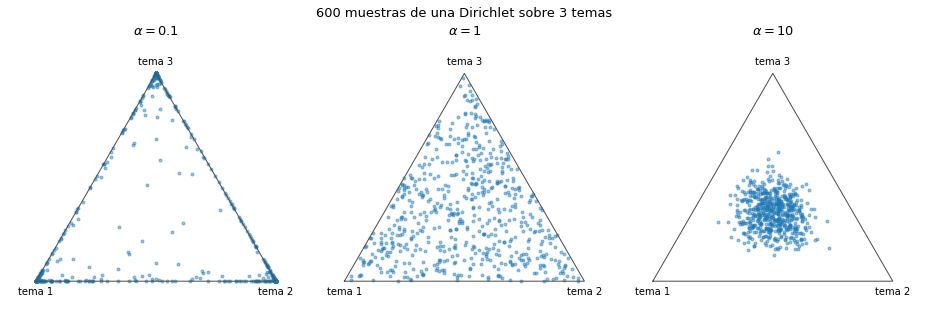

In [28]:
import matplotlib.pyplot as plt

def a_triangulo(P):
    # coordenadas baricéntricas -> plano: cada vértice es un tema puro
    v = np.array([[0.0, 0.0], [1.0, 0.0], [0.5, np.sqrt(3) / 2]])
    return P @ v

fig, axes = plt.subplots(1, 3, figsize=(13, 4.6))
v = np.array([[0.0, 0.0], [1.0, 0.0], [0.5, np.sqrt(3) / 2], [0.0, 0.0]])
rng_d = np.random.default_rng(1)

for ax, a in zip(axes, [0.1, 1.0, 10.0]):
    P = a_triangulo(rng_d.dirichlet([a, a, a], size=600))
    ax.plot(v[:, 0], v[:, 1], color='0.3', lw=1)
    ax.scatter(P[:, 0], P[:, 1], s=9, alpha=0.45)
    ax.set_title(r'$\alpha = %g$' % a, fontsize=13)
    for (x, y), etq in zip(v[:3], ['tema 1', 'tema 2', 'tema 3']):
        ax.annotate(etq, (x, y), textcoords='offset points',
                    xytext=(0, -14 if y == 0 else 8), ha='center', fontsize=10)
    ax.set_xlim(-0.12, 1.12); ax.set_ylim(-0.14, 1.0)
    ax.set_aspect('equal'); ax.axis('off')

fig.suptitle('600 muestras de una Dirichlet sobre 3 temas', fontsize=13)
plt.tight_layout(); plt.show()


$\eta$ funciona igual: controla qué tan concentrado es cada **tema** sobre el vocabulario. Con $\eta$ chico, un tema pone casi toda su probabilidad en pocas palabras, que es lo que hace que los tópicos resulten legibles. Con $\eta$ grande, cada tema reparte entre todo el vocabulario y ningún tópico es claramente identificable.

# Ingenieria Reversa


> Nos entregan **solo las palabras**. ¿Cómo recuperamos los temas $\beta$, las
> mezclas $\theta$ y las asignaciones $z$ que las produjeron?


Usamos maxima verosimilitud?

Para un documento $d$, la probabilidad de las palabras que observamos es la de todos los caminos posibles que pudieron generarlas, sumada sobre las asignaciones que no vemos e integrada sobre la mezcla que no vemos:

$$p(\mathbf{w}_d \mid \alpha, \beta) \;=\;
\int p(\theta_d \mid \alpha)
\left( \prod_{n=1}^{N_d} \sum_{k=1}^{K}
p(z_{dn} = k \mid \theta_d)\; p(w_{dn} \mid \beta_k) \right) d\theta_d$$


Paso por paso

- La suma $\sum_k$ dice *"la palabra $w_{dn}$ pudo venir de cualquiera de los $K$
  temas, y no sabemos de cuál"*.
- El producto $\prod_n$ dice *"y esto pasó para cada una de las $N_d$ palabras"*.
- La integral dice *"y además la mezcla $\theta_d$ tampoco la vimos, así que hay
  que promediar sobre todas las mezclas posibles"*.


Sin embargo esto nos genera un problema: la suma sobre $k$ está *adentro* del producto sobre $n$. Si estuviera afuera, el logaritmo
partiría el producto en una suma y todo sería fácil. Adentro, no: al expandir el producto de sumas quedan $K^{N_d}$ términos, y cada uno acopla $\theta_d$ con $\beta$. La integral no tiene forma cerrada.



Como la integral no se puede resolver directamente, se a aproxima. Tipicamente se usan dos caminos:

**Muestreo de Gibbs colapsado.** En vez de calcular el posterior, se lo muestrea. Se integran analíticamente $\theta$ y $\beta$ —eso es lo que quiere decir *colapsado*— y queda un muestreador que solo reasigna las $z$, una palabra a la vez.

**Inferencia variacional.** En vez de muestrear el posterior, se lo aproxima: se elige una familia de distribuciones simples y se busca la más parecida al posterior verdadero. Eso convierte la integral en una optimización, cuyo objetivo es una
**cota inferior** de la verosimilitud. Es lo que implementa `scikit-learn`, siguiendo a Hoffman, Bach y Blei (2010); nosotros usamos su variante `'batch'`, que recorre todo el corpus en cada iteración.


## Implememtemos

In [29]:
# LDA con 4 tópicos, alpha=0.35, eta=0.01, método batch y 50 iteraciones
from sklearn.decomposition import LatentDirichletAllocation

lda = LatentDirichletAllocation(
    n_components=4,
    doc_topic_prior=0.35,      # alpha
    topic_word_prior=0.01,     # eta
    learning_method='batch',
    max_iter=50,
    random_state=123,
)
Theta = lda.fit_transform(X)

# Theta es la matriz de distribución de tópicos por documento, donde cada fila corresponde a un documento y cada columna a un tópico. 
# # Cada elemento Theta[i, j] representa la proporción del tópico j en el documento i.
Theta

array([[0.16014915, 0.72427464, 0.10799837, 0.00757785],
       [0.66463444, 0.01542591, 0.01477995, 0.3051597 ],
       [0.01178658, 0.26321889, 0.71372702, 0.01126751],
       ...,
       [0.01122846, 0.82132662, 0.15624516, 0.01119976],
       [0.92529601, 0.0247297 , 0.02543658, 0.02453771],
       [0.02276087, 0.66295747, 0.02629638, 0.28798527]])

In [30]:

def top_palabras(modelo, vocabulario, n=8):
    B = modelo.components_ / modelo.components_.sum(axis=1, keepdims=True)
    return pd.DataFrame(
        [vocabulario[np.argsort(B[k])[::-1][:n]] for k in range(B.shape[0])],
        index=['tópico %d' % k for k in range(B.shape[0])],
        columns=['#%d' % (i + 1) for i in range(n)])

top_palabras(lda, vocab)

,#1,#2,#3,#4,#5,#6,#7,#8
tópico 0,espacio,lugar,terraza,ambiente,decoracion,luz,sillas,musica
tópico 1,valor,cuenta,precio,precios,factura,promocion,economico,carta
tópico 2,plato,sabor,comida,sazon,menu,postre,porcion,llego
tópico 3,pedido,mesero,mesa,atencion,pendiente,nadie,tiempo,personal



Miremos esos cuatro tópicos con cuidado  y comparemos con lo que sabemos que hay: comida, servicio, precio y ambiente.


**No le dijimos al algoritmo que existían cuatro temas ni cuáles eran.** Le dimos 800 bolsas de palabras y el número 4.


Hay que tener cuidado que el orden no necesariamente es el mismo, el tópico 0 del modelo no tiene por qué ser el tema 0 nuestro. Los tópicos salen sin nombre y en un orden que depende del ajuste.


## Consideraciones sobre LDA

- Los grupos de palabras que forman un tópico **no están relacionados conceptualmente**: están relacionados por proximidad. Aparecen juntos seguido en los mismos documentos, y eso es todo lo que el modelo sabe.

- La suposición de fondo es que todas las palabras de un documento están relacionadas. Puede ser falsa, y las palabras pueden ser demasiado genéricas como para formar tópicos coherentes.
- Con datos ruidosos, el modelo va a asignar palabras sin relación a algún tópico. Eso no es necesariamente una falla: es que el modelo está extrayendo particularidades de los datos, que pueden venir de **cómo, dónde o cuándo se recogieron**.
- Interpretar tópicos abstractos es equilibrar lo que los datos traen de suyo con las agrupaciones que el modelo generó. Es trabajo de quien analiza, no del algoritmo.

Y la de siempre: *garbage in, garbage out*. Si entra basura, sale basura. En este ejemplo nosotros fabricamos el corupus y estaba limpio a propósito; con texto real, la limpieza es la parte clave del trabajo

# ¿Cuántos tópicose elegir?

Hoy hicimos trampa, le dimos el número 4 porque lo sabíamos. En cualquier problema real no se sabe, y $K$ es clave.

Hay al menos 3 criterios

## Criterios 1 y 2: la perplejidad, dentro (1) y fuera (2) de muestra

La **perplejidad** mide qué "tan sorprendido" queda el modelo ante un texto. Mide el ajuste del modelo. Puesto que tenemos una verosimilitud, es intuitivo, usamos el exponencial de la log-verosimilitud negativa por palabra, así que **más baja es mejor**: el modelo le asignaba alta probabilidad a las palabras que efectivamente aparecieron.

La clave es **dónde** medimos:

- **Dentro de muestra**, sobre el mismo corpus con el que se ajustó. Más tópicos casi siempre la bajan, por la misma razón por la que más regresores casi siempre suben el $R^2$.
- **Fuera de muestra**, sobre documentos que el modelo no vio. Para eso partimos el corpus en 75 % de entrenamiento y 25 % de prueba.



In [31]:
from sklearn.model_selection import train_test_split

X_entrena, X_prueba = train_test_split(X, test_size=0.25, random_state=123)




filas = []
for K in range(2, 11):
    m_todo = LatentDirichletAllocation(n_components=K, doc_topic_prior=0.35,
                                      topic_word_prior=0.01, learning_method='batch',
                                      max_iter=50, random_state=123).fit(X_prueba)
    m_entrena = LatentDirichletAllocation(n_components=K, doc_topic_prior=0.35,
                                      topic_word_prior=0.01, learning_method='batch',
                                      max_iter=50, random_state=123).fit(X_entrena)
    filas.append({
        'K': K,
        'perplejidad dentro de muestra': m_todo.perplexity(X_entrena),
        'perplejidad fuera de muestra': m_entrena.perplexity(X_prueba),
    })

curvas = pd.DataFrame(filas).set_index('K')
curvas.round(3)

,perplejidad dentro de muestra,perplejidad fuera de muestra
K,,
2,185.185,193.293
3,164.232,178.594
4,155.466,151.424
5,130.042,145.345
6,130.337,148.087
7,130.036,147.619
8,130.567,149.216
9,131.680,151.012
10,129.941,152.443



## Criterio 3: coherencia

La **coherencia** no mira la verosimilitud sino las palabras: toma las $M$ palabras más probables de cada tópico, acá $M = 10$, y pregunta si suelen aparecer juntas en los documentos. 

$$\text{NPMI}(w_i, w_j) = \frac{\log \dfrac{P(w_i, w_j)}{P(w_i)P(w_j)}}{-\log P(w_i, w_j)}$$

donde las probabilidades se estiman contando en cuántos documentos aparece cada palabra y en cuántos aparecen las dos. Va de $-1$ a $1$; **más alto es mejor**.

No es la única medida de coherencia ni la mejor: Röder, Both y Hinneburg (2015) mapean toda la familia y proponen $C_V$, que es la que suelen traer las librerías especializadas. NPMI es la más simple de escribir.

In [32]:
import itertools

Binaria = (X.toarray() > 0).astype(int)
n_docs = Binaria.shape[0]
df_pal = Binaria.sum(axis=0)              # en cuántos documentos aparece cada palabra
co_ocurre = Binaria.T @ Binaria           # en cuántos aparecen las dos

def coherencia_npmi(modelo, M=10):
    B = modelo.components_ / modelo.components_.sum(axis=1, keepdims=True)
    por_topico = []
    for k in range(B.shape[0]):
        top = np.argsort(B[k])[::-1][:M]
        pares = []
        for a, b in itertools.combinations(top, 2):
            p_ab = (co_ocurre[a, b] + 1e-12) / n_docs
            p_a, p_b = df_pal[a] / n_docs, df_pal[b] / n_docs
            pares.append(np.log(p_ab / (p_a * p_b)) / (-np.log(p_ab)))
        por_topico.append(np.mean(pares))
    return float(np.mean(por_topico))

print('coherencia NPMI del modelo de 4 tópicos: %.4f' % coherencia_npmi(lda))

coherencia NPMI del modelo de 4 tópicos: 0.2860


In [33]:

# Corpus de referencia que utilizará coherencia_npmi
Binaria = (X_entrena.toarray() > 0).astype(int)
n_docs = Binaria.shape[0]
df_pal = Binaria.sum(axis=0)
co_ocurre = Binaria.T @ Binaria

filas = []
for K in range(2, 11):
    m_entrena = LatentDirichletAllocation(
        n_components=K,
        doc_topic_prior=0.35,
        topic_word_prior=0.01,
        learning_method='batch',
        max_iter=50,
        random_state=123
    ).fit(X_entrena)

    filas.append({
        'K': K,
        'perplejidad dentro de muestra': m_entrena.perplexity(X_entrena),
        'perplejidad fuera de muestra': m_entrena.perplexity(X_prueba),
        'coherencia NPMI (entrenamiento)': coherencia_npmi(m_entrena),
    })

curvas = pd.DataFrame(filas).set_index('K')
curvas.round(3)

,perplejidad dentro de muestra,perplejidad fuera de muestra,coherencia NPMI (entrenamiento)
K,,,
2,158.403,193.293,0.118
3,142.960,178.594,0.254
4,122.873,151.424,0.290
5,119.067,145.345,0.318
6,121.120,148.087,0.331
7,120.300,147.619,0.317
8,120.005,149.216,0.293
9,118.803,151.012,0.328
10,118.747,152.443,0.322


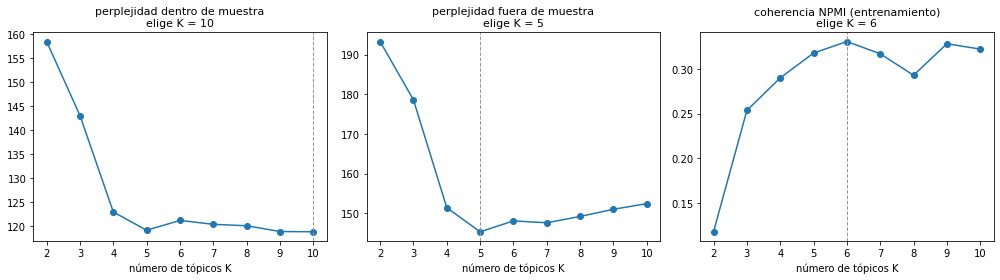

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col_nom, mejor in zip( axes, curvas.columns, [np.argmin, np.argmin, np.argmax]):
    y = curvas[col_nom]
    ax.plot(y.index, y.values, marker='o')
    k_opt = y.index[mejor(y.values)]
    ax.axvline(k_opt, color='0.6', ls='--', lw=1)
    ax.set_title('%s\nelige K = %d' % (col_nom, k_opt), fontsize=11)
    ax.set_xlabel('número de tópicos K')
    ax.set_xticks(list(y.index))
plt.tight_layout(); plt.show()

## Tres criterios para elegir el número de tópicos

Los tres criterios considerados pueden llevar a elecciones distintas de \(K\), porque evalúan aspectos diferentes del modelo.

**Perplejidad dentro de muestra.** En este ejercicio, la perplejidad evaluada sobre los mismos documentos utilizados para estimar el modelo disminuye a medida que aumenta \(K\). El resultado es esperable: al incorporar más tópicos, el modelo dispone de mayor flexibilidad para representar los datos de entrenamiento. Por esta razón, la perplejidad dentro de muestra no ofrece, por sí sola, un criterio adecuado para seleccionar \(K\): puede favorecer modelos cada vez más complejos sin penalizar suficientemente el sobreajuste.

**Perplejidad fuera de muestra.** La situación cambia cuando la evaluación se realiza sobre documentos que no participaron en la estimación. La diferencia con el criterio anterior no está en la métrica, sino en el conjunto de datos sobre el que se calcula. Evaluar fuera de muestra permite medir mejor la capacidad de generalización del modelo y, por tanto, distinguir entre un aumento útil de complejidad y un simple mejor ajuste a los datos de entrenamiento.

**Coherencia de los tópicos.** La coherencia, en cambio, favorece en este ejercicio valores de \(K\) mayores. Esto tampoco implica un error en el cálculo. La coherencia mide, en términos generales, hasta qué punto las palabras más representativas de un tópico tienden a aparecer juntas. Al aumentar el número de tópicos, un tema amplio puede dividirse en subtemas más específicos cuyas palabras presentan una co-ocurrencia elevada. Como resultado, la coherencia puede mejorar incluso cuando la partición obtenida es demasiado fina para el objetivo sustantivo del análisis.

Estas diferencias ilustran que no existe una única métrica automática que resuelva por completo la elección del número de tópicos. Además, una mejor capacidad predictiva no garantiza una mayor interpretabilidad. Chang et al. (2009), en *Reading Tea Leaves: How Humans Interpret Topic Models*, muestran precisamente que los modelos con mejor desempeño en términos de perplejidad no necesariamente producen los tópicos que las personas consideran más interpretables.

En la práctica, conviene utilizar estos criterios de manera complementaria. La perplejidad fuera de muestra puede ayudar a identificar un rango razonable de valores de \(K\); la coherencia aporta información sobre la asociación entre las palabras que conforman cada tópico; y la inspección sustantiva de los tópicos permite evaluar si la solución obtenida es interpretable y útil para el problema de investigación. La elección final de \(K\) debe apoyarse en el conjunto de estas evidencias, y no en una única métrica.


# Palabras finales: LDA no es un LLM

Vale la pena cerrar con una distinción importante. LDA es un modelo de **tópicos**, no un modelo de lenguaje.

La diferencia está en un supuesto que atraviesa todo el modelo: LDA trata cada documento como una **bolsa de palabras**. Importa qué palabras aparecen y con qué frecuencia, pero no el orden en que lo hacen. Para LDA, `no me gustó nada` y `nada me gustó, no` contienen exactamente la misma información.

Los modelos de lenguaje modernos parten de una idea muy distinta. El orden y el contexto son centrales: una palabra se interpreta en función de las que la rodean. Por eso `banco` en *“me senté en el banco”* y en *“fui al banco”* puede recibir representaciones diferentes. En LDA, en cambio, ambas apariciones corresponden a la misma palabra del vocabulario.

Esto puede hacer que LDA parezca limitado frente a modelos más recientes. Y, en cierto sentido, lo es. Pero esa comparación también ayuda a entender por qué sigue siendo útil.

LDA ofrece un excelente **bang for the buck** (algo así como **“mucho rendimiento por poco costo”** o **“mucho valor por lo que cuesta”**). Con un modelo relativamente simple y barato de estimar, podemos explorar miles de documentos, detectar estructuras temáticas sin etiquetas previas y obtener resultados que pueden inspeccionarse directamente. Un tópico puede leerse como una distribución de palabras, compararse con otros tópicos, discutirse y cuestionarse.

Esa combinación de bajo costo, escalabilidad e interpretabilidad sigue siendo valiosa. No siempre necesitamos el modelo más complejo disponible; necesitamos un modelo adecuado para la pregunta que queremos responder.

Además, LDA deja una última enseñanza que va más allá del análisis de textos. Su estructura reúne muchas de las ideas centrales de la modelación probabilística moderna: un proceso generativo, variables latentes, distribuciones previas, una verosimilitud que no podemos manipular directamente e inferencia aproximada para recuperar aquello que no observamos.

Por eso estudiar LDA no es solamente aprender una técnica para descubrir tópicos. Es aprender, en un problema relativamente manejable, una forma de pensar que reaparece una y otra vez en modelos mucho más complejos.


# Referencias

- Blei, D. M., Ng, A. Y., y Jordan, M. I. (2003). Latent Dirichlet Allocation.
  *Journal of Machine Learning Research*, 3, 993–1022.
- Hoffman, M., Bach, F., y Blei, D. (2010). Online Learning for Latent Dirichlet
  Allocation. *Advances in Neural Information Processing Systems*, 23. Es el
  algoritmo que implementa `scikit-learn`.
- Chang, J., Boyd-Graber, J., Gerrish, S., Wang, C., y Blei, D. (2009). Reading Tea
  Leaves: How Humans Interpret Topic Models. *Advances in Neural Information
  Processing Systems*, 22.
- Röder, M., Both, A., y Hinneburg, A. (2015). Exploring the Space of Topic
  Coherence Measures. *Proceedings of the Eighth ACM International Conference on Web
  Search and Data Mining*, 399–408.
- Jurafsky, D., y Martin, J. H. *Speech and Language Processing*, 3.ª edición
  (borrador en línea). Capítulos de expresiones regulares y de vectores semánticos.
- Bird, S., Klein, E., y Loper, E. (2009). *Natural Language Processing with
  Python*. O'Reilly.


# Información de Sesión

In [35]:
import session_info
session_info.show(html=False)

-----
contexto            NA
matplotlib          3.5.3
numpy               1.21.6
pandas              1.3.5
pkg_resources       NA
scipy               1.4.1
session_info        1.0.0
sklearn             1.0.2
spacy               3.6.1
utils               NA
-----
IPython             7.14.0
jupyter_client      6.1.3
jupyter_core        4.6.3
jupyterlab          2.1.1
notebook            6.0.3
-----
Python 3.7.6 | packaged by conda-forge | (default, Mar 23 2020, 23:03:20) [GCC 7.3.0]
Linux-6.5.0-1024-aws-x86_64-with-debian-buster-sid
-----
Session information updated at 2026-09-08 01:50
